# Operations, Monitoring & Evidence
Covers **Stage 4.** Complete every `# TODO` in this notebook **and** in the `src/` modules it imports. 
- Each stage opens with a **sub-task checklist**
- Capture any repo-generated evidence (MLflow UI, Docker build, CI run, drift report) as screenshots/summaries **inside the notebook/report**.

**File ownership** — 
- *Provided:* `config.py`, `src/evaluate.py`. 
- *Provided to extend:* `src/monitoring.py`, `src/retrain.py`, `src/model.py` (EmbeddingExtractor). 
- *You build:* this notebook.

### 0. Setup

In [1]:
import config, json
# TODO: load artifacts/drift_summary.json after running src.monitoring
import json

import config

# Set the drift summary path by joining the artifact directory with the filename "drift_summary.json".
drift_summary_path = (
    config.ARTIFACT_DIR
    / "drift_summary.json"
)

# If the drift summary file exists, read its contents and load it as a JSON object. 
# Otherwise, set drift_summary to None and print a message indicating that the drift summary is not available yet.
if drift_summary_path.exists():
    drift_summary = json.loads(
        drift_summary_path.read_text(
            encoding="utf-8"
        )
    )

    print(
        "Loaded drift summary:",
        drift_summary_path,
    )
else:
    drift_summary = None

    print(
        "Drift summary not available yet."
    )
    print(
        "Run `python -m src.monitoring` "
        "after completing the monitoring implementation."
    )

Loaded drift summary: C:\Users\naren\Documents\MLOps-Capstone\capstone\artifacts\drift_summary.json


In [2]:
# Assert that the drift summary is not None to ensure that the drift summary has been successfully loaded 
# before proceeding with further analysis or printing its contents.
assert drift_summary is not None

print(
    "Retraining recommended:",
    drift_summary["retrain_recommended"],
)

print(
    "Trigger reasons:",
    drift_summary["trigger_reasons"],
)

Retraining recommended: True
Trigger reasons: ['feature_drift', 'embedding_drift']


In [4]:
# Generate a small set of served predictions for monitoring evidence.

import mimetypes

from fastapi.testclient import TestClient

from app import app
from src import data_prep


# Load the versioned test split.
data_root = data_prep.find_data_root()

# Load the test split of the dataset using the data_prep module, specifying the version and name of the split, 
# and providing the root directory where the data is located.
test_items = data_prep.load_split(
    version="v1",
    name="test",
    root=data_root,
)

# Select 3 examples from each class.
ok_examples = [
    (path, label)
    for path, label in test_items
    if label == config.CLASS_TO_IDX["ok_front"]
][:3]

defect_examples = [
    (path, label)
    for path, label in test_items
    if label == config.CLASS_TO_IDX["def_front"]
][:3]

examples_to_serve = (
    ok_examples
    + defect_examples
)

print(
    "Images selected:",
    len(examples_to_serve),
)


# Calling the real FastAPI endpoint also exercises
# the production prediction-logging path.

# Pass the FastAPI app instance to the TestClient, which allows for testing the API endpoints without running a live server.
with TestClient(app) as client:

    # Check the health of the FastAPI application by sending a GET request to the "/health" endpoint 
    # and asserting that the response status code is 200 and that the model is loaded successfully.
    health_response = client.get(
        "/health"
    )

    assert health_response.status_code == 200
    assert health_response.json()[
        "model_loaded"
    ] is True

    prediction_results = []

    # Iterate over the selected examples to serve, sending each image to the "/predict" endpoint of the FastAPI application
    for image_path, true_label in examples_to_serve:

        content_type = (
            mimetypes.guess_type(
                image_path.name
            )[0]
            or "application/octet-stream"
        )

        # Open the image file in binary mode and send a POST request to the "/predict" endpoint with the image file as part of the request.
        with image_path.open("rb") as image_file:

            response = client.post(
                "/predict",
                files={
                    "file": (
                        image_path.name,
                        image_file,
                        content_type,
                    )
                },
            )

        # Assert that the response status code is 200 to ensure that the prediction request was successful.
        assert response.status_code == 200, (
            response.text
        )

        result = response.json()

        # Append the prediction results, including the filename, true label, predicted label, confidence score, 
        # and probability of defect, to the prediction_results list for further analysis and display.
        prediction_results.append(
            {
                "filename": image_path.name,
                "true_label": (
                    config.IDX_TO_CLASS[
                        true_label
                    ]
                ),
                "predicted_label": (
                    result["label"]
                ),
                "confidence": (
                    result["confidence"]
                ),
                "prob_defect": (
                    result["prob_defect"]
                ),
            }
        )

import pandas as pd

prediction_results_df = pd.DataFrame(
    prediction_results
)

display(
    prediction_results_df
)

print(
    "PASS:",
    len(prediction_results),
    "images served through /predict.",
)

Images selected: 6


,filename,true_label,predicted_label,confidence,prob_defect
0,cast_ok_0_10.jpeg,ok_front,ok_front,0.799578,0.200422
1,cast_ok_0_1141.jpeg,ok_front,ok_front,0.711781,0.288219
2,cast_ok_0_1145.jpeg,ok_front,ok_front,0.890489,0.109511
3,cast_def_0_1059.jpeg,def_front,def_front,0.653675,0.653675
4,cast_def_0_1063.jpeg,def_front,def_front,0.657682,0.657682
5,cast_def_0_108.jpeg,def_front,def_front,0.993619,0.993619


PASS: 6 images served through /predict.


## **Stage 4.1 — Prediction Logging & Confidence Monitoring** <font color="red">[5 marks]</font>

- **4.1.1 — Prediction logging with timestamp [2]** — *to be done in this notebook and the report*
- **4.1.2 — Confidence monitoring reference vs current + threshold [3]** — *to be done in this notebook and the report*

**Objective:** Log predictions and watch mean confidence drift.

**Implement in:** app.py (logging) + src/monitoring.py (confidence)

**Inputs → Outputs:** served predictions → predictions.log; reference vs current → confidence drop + alert

**TODO:** log each prediction with a timestamp (4.1.1); compute mean predicted-confidence on reference vs a current batch with an alert threshold (4.1.2).

**Depends on:** Stage 3.4 completed in Model_Development_and_Tracking.ipynb ·  **Document here:** the confidence reference→current + log tail.

In [5]:
# TODO 4.1.1-4.1.2: show predictions.log tail + confidence block from drift_summary.json
# Stage 4.1.1 — Prediction logging with timestamp

from collections import deque

import pandas as pd
from IPython.display import display

import config
import json

prediction_log_path = config.PREDICTIONS_LOG

# Assert that the prediction log file exists to ensure that predictions have been logged before attempting to read and display them.
assert prediction_log_path.exists(), (
    f"Prediction log not found: {prediction_log_path}"
)

# Read only the most recent predictions rather than loading
# an indefinitely growing production log.

# Use a deque to efficiently retrieve the last 5 non-empty lines from the prediction log file, stripping any leading 
# or trailing whitespace from each line.
with prediction_log_path.open(
    "r",
    encoding="utf-8",
) as log_file:
    recent_lines = list(
        deque(
            (
                line.strip()
                for line in log_file
                if line.strip()
            ),
            maxlen=5,
        )
    )

# Convert the recent lines from the prediction log into a list of JSON objects by loading each line as a JSON record.
recent_predictions = [
    json.loads(line)
    for line in recent_lines
]

# Assert that there are recent predictions to display, ensuring that the prediction log contains 
# records before attempting to process and display them.
assert recent_predictions, (
    "Prediction log exists but contains no records."
)

# Confirm that every displayed prediction contains a timestamp.
assert all(
    "timestamp_utc" in record
    for record in recent_predictions
)

# Define the columns to be displayed from the prediction log, including timestamp, filename, label, defect status, 
# probability of defect, confidence score, and latency in milliseconds.
prediction_columns = [
    "timestamp_utc",
    "filename",
    "label",
    "is_defective",
    "prob_defect",
    "confidence",
    "latency_ms",
]

# Create a DataFrame from the recent predictions to facilitate structured display and analysis of the prediction records.
prediction_log_tail = pd.DataFrame(
    recent_predictions
)

# Display the relevant columns from the prediction log tail, filtering to include only those columns that are present in the DataFrame.
display(
    prediction_log_tail[
        [
            column
            for column in prediction_columns
            if column in prediction_log_tail.columns
        ]
    ]
)

print(
    f"PASS: displaying the latest "
    f"{len(recent_predictions)} prediction record(s)."
)

print(
    "Prediction log:",
    prediction_log_path,
)

,timestamp_utc,filename,label,is_defective,prob_defect,confidence,latency_ms
0,2026-08-17T06:20:28.699002+00:00,cast_ok_0_1141.jpeg,ok_front,False,0.288219,0.711781,30.335
1,2026-08-17T06:20:28.788875+00:00,cast_ok_0_1145.jpeg,ok_front,False,0.109511,0.890489,89.328
2,2026-08-17T06:20:28.822217+00:00,cast_def_0_1059.jpeg,def_front,True,0.653675,0.653675,29.015
3,2026-08-17T06:20:28.847134+00:00,cast_def_0_1063.jpeg,def_front,True,0.657682,0.657682,23.828
4,2026-08-17T06:20:28.881988+00:00,cast_def_0_108.jpeg,def_front,True,0.993619,0.993619,29.539


PASS: displaying the latest 5 prediction record(s).
Prediction log: C:\Users\naren\Documents\MLOps-Capstone\capstone\artifacts\predictions.log


In [6]:
# Stage 4.1.2 — Reference vs current confidence monitoring

# Assert that the drift summary is not None to ensure that the drift summary has been successfully loaded 
# before proceeding with further analysis or printing its contents.
assert drift_summary is not None, (
    "Run src.monitoring before displaying confidence results."
)

# Extract the confidence metrics from the drift summary for further analysis and display.
confidence = drift_summary["confidence"]

# Extract individual confidence metrics from the confidence dictionary for easier access and display.
reference_mean = confidence["reference_mean"]
current_mean = confidence["current_mean"]
confidence_drop = confidence["drop"]
threshold = confidence["threshold"]
alert = confidence["alert"]

# Create a DataFrame to summarize the confidence metrics, including reference mean confidence, current mean confidence,
# confidence drop, and the alert threshold, for structured display and analysis.
confidence_results = pd.DataFrame(
    {
        "Metric": [
            "Reference mean confidence",
            "Current mean confidence",
            "Confidence drop",
            "Alert threshold",
        ],
        "Value": [
            reference_mean,
            current_mean,
            confidence_drop,
            threshold,
        ],
    }
)

# Display the confidence results DataFrame with formatted values for better readability, 
# showing the metrics and their corresponding values.
display(
    confidence_results.style.format(
        {
            "Value": "{:.4f}",
        }
    )
)

print(
    "Confidence alert:",
    alert,
)

if alert:
    print(
        "ALERT: mean confidence has dropped "
        "beyond the configured threshold."
    )
else:
    print(
        "PASS: confidence drop does not exceed "
        "the configured threshold."
    )

,Metric,Value
0,Reference mean confidence,0.8706
1,Current mean confidence,0.8293
2,Confidence drop,0.0412
3,Alert threshold,0.1000


Confidence alert: False
PASS: confidence drop does not exceed the configured threshold.


### Stage 4.1 interpretation

Production monitoring includes prediction logging and model-confidence
monitoring. Successful predictions made through the FastAPI `/predict`
endpoint are written to `predictions.log` as JSON Lines records containing the
UTC timestamp, uploaded filename, content type, predicted class, defect
probability, prediction confidence and inference latency. This provides an
auditable record of served predictions that can later be aggregated for
operational monitoring.

Confidence monitoring was performed using the complete 995-image validation
partition associated with production dataset version `v1` as the clean
reference baseline. A simulated current production batch of the same size was
created by applying controlled camera and image-quality corruption.

The mean prediction confidence on the clean reference batch was approximately
0.8706, compared with 0.8293 on the simulated current batch. This represents
an absolute confidence reduction of approximately 0.0412.

The configured confidence-drop alert threshold is 0.10, so the observed
reduction did not independently trigger a confidence alert.

This result illustrates the benefit of using multiple monitoring signals.
Although average confidence remained within the configured tolerance, both
statistical image-feature drift and embedding-space drift were detected by the
other monitoring components.

## **Stage 4.2 — Statistical Drift Detection (Evidently + PSI)** <font color="red">[8 marks]</font>

- **4.2.1 — Per-image features + Evidently DataDriftPreset [4]** — *to be done in this notebook and the report*
- **4.2.2 — PSI per feature + interpretation [4]**— *to be done in this notebook and the report*

**Objective:** Detect drift in interpretable image features.

**Implement in:** src/monitoring.py

**Inputs → Outputs:** reference vs simulated current batch → per-feature drift + PSI + HTML report

**TODO:** compute image features + run Evidently DataDriftPreset reference vs a simulated current batch (4.2.1); compute PSI per feature + interpret + save drift_report.html (4.2.2).

**Document here:** the per-feature PSI table/plot + dataset_drift flag.

In [7]:
# TODO 4.2.1-4.2.2: !python -m src.monitoring ; bar-plot feature PSI vs the 0.2 threshold
# Stage 4.2.1 — Statistical drift detection using interpretable image features

import pandas as pd
from IPython.display import display, FileLink

# Assert that the drift summary is not None to ensure that the drift summary has been successfully loaded 
# before proceeding with further analysis and display of drift results.
assert drift_summary is not None, (
    "Run `python -m src.monitoring` before displaying drift results."
)

# Extract the feature drift information from the drift summary for further analysis and display.
feature_drift = drift_summary["feature_drift"]

# Extract individual feature drift metrics from the feature_drift dictionary for easier access and display.
feature_psi = feature_drift["psi"]
psi_threshold = feature_drift["threshold"]
drifted_features = feature_drift["drifted_features"]
drift_share = feature_drift["drift_share"]
dataset_drift = feature_drift["dataset_drift"]

# Define the path to the drift report by joining the artifact directory with the filename "drift_report.html".
drift_report_path = (
    config.ARTIFACT_DIR
    / "drift_report.html"
)

# Check if the drift report file exists and assert its existence to ensure that the drift report has been 
# generated before attempting to display it.
assert drift_report_path.exists(), (
    f"Evidently drift report not found: {drift_report_path}"
)

# Print the monitored image features, drifted features, drifted feature share, and whether dataset drift was detected,
# providing a summary of the drift analysis results.
print(
    "Monitored image features:",
    list(feature_psi.keys()),
)

print(
    "Drifted features:",
    drifted_features,
)

print(
    f"Drifted feature share: {drift_share:.2%}"
)

print(
    "Dataset drift detected:",
    dataset_drift,
)

print(
    "\nEvidently report:"
)

display(
    FileLink(
        str(drift_report_path)
    )
)

Monitored image features: ['brightness', 'contrast', 'edge_density', 'sharpness', 'mean_intensity']
Drifted features: ['brightness', 'contrast', 'edge_density', 'sharpness', 'mean_intensity']
Drifted feature share: 100.00%
Dataset drift detected: True

Evidently report:


C:\Users\naren\Documents\MLOps-Capstone\capstone\artifacts\drift_report.html

In [8]:
# Stage 4.2.2 — Per-feature Population Stability Index

# Create a DataFrame to summarize the Population Stability Index (PSI) for each feature, including the PSI value,
# the threshold for drift detection, and whether the feature is considered drifted based on the PSI value exceeding the threshold.
psi_table = pd.DataFrame(
    {
        "Feature": list(
            feature_psi.keys()
        ),
        "PSI": list(
            feature_psi.values()
        ),
    }
)

psi_table["Threshold"] = (
    psi_threshold
)

psi_table["Drifted"] = (
    psi_table["PSI"]
    > psi_table["Threshold"]
)

# Display the PSI table with formatted values for better readability, showing the feature names, PSI values, thresholds, and drift status.
display(
    psi_table.style.format(
        {
            "PSI": "{:.4f}",
            "Threshold": "{:.2f}",
        }
    )
)

# Assert that the number of drifted features in the PSI table matches the length of the drifted_features list 
# to ensure consistency between the two representations of drifted features.
assert (
    psi_table["Drifted"].sum()
    == len(drifted_features)
)

print(
    f"{psi_table['Drifted'].sum()} of "
    f"{len(psi_table)} features exceeded "
    f"the PSI threshold of {psi_threshold:.2f}."
)

,Feature,PSI,Threshold,Drifted
0,brightness,12.4219,0.20,True
1,contrast,12.4219,0.20,True
2,edge_density,12.4220,0.20,True
3,sharpness,12.4219,0.20,True
4,mean_intensity,12.4219,0.20,True


5 of 5 features exceeded the PSI threshold of 0.20.


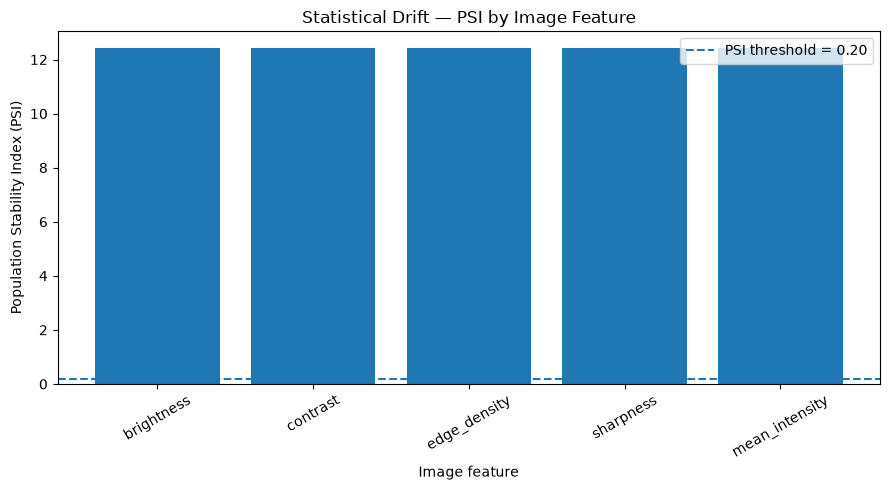

In [9]:
# Visualise per-feature PSI against the configured threshold.

import matplotlib.pyplot as plt


fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.bar(
    psi_table["Feature"],
    psi_table["PSI"],
)

ax.axhline(
    y=psi_threshold,
    linestyle="--",
    label=f"PSI threshold = {psi_threshold:.2f}",
)

ax.set_title(
    "Statistical Drift — PSI by Image Feature"
)

ax.set_xlabel(
    "Image feature"
)

ax.set_ylabel(
    "Population Stability Index (PSI)"
)

ax.tick_params(
    axis="x",
    rotation=30,
)

ax.legend()

plt.tight_layout()
plt.show()

In [10]:
drift_share_threshold = feature_drift[
    "drift_share_threshold"
]

print(
    f"Drifted feature share : {drift_share:.2%}"
)

print(
    f"Trigger threshold      : {drift_share_threshold:.2%}"
)

print(
    f"Dataset drift          : {dataset_drift}"
)

Drifted feature share : 100.00%
Trigger threshold      : 40.00%
Dataset drift          : True


### Stage 4.2 interpretation

Statistical data drift was evaluated by comparing the clean production
reference baseline with a simulated current batch. Both batches contained 995
images from dataset version `v1`; the current images were generated by applying
controlled lighting, blur, rotation and noise corruption to the corresponding
clean reference images.

Five interpretable image characteristics were monitored: brightness, contrast,
edge density, sharpness and mean intensity. Population Stability Index (PSI)
was calculated for each feature using reference-derived quantile bins.

The observed PSI values were approximately:

- brightness: 12.4219
- contrast: 12.4219
- edge density: 12.4220
- sharpness: 12.4219
- mean intensity: 12.4219

All five features exceeded the configured PSI drift threshold of 0.20.
Consequently, 5 of 5 monitored features were classified as drifted, producing
a drift share of 100%.

The configured dataset-level trigger requires at least 40% of monitored
features to drift. Because the observed drift share was 100%, dataset drift
was therefore detected.

The very large and similar PSI values indicate that the deliberately corrupted
current distributions have become almost completely separated from the clean
reference distributions under the reference-derived PSI bins. They should
therefore be interpreted as evidence of severe simulated drift rather than as
meaningful rankings of drift magnitude between individual features.

An Evidently DataDriftPreset report was also generated and saved as
`drift_report.html` to provide an inspectable statistical-drift artifact.

## **Stage 4.3 — Embedding Drift Detection** <font color="red">[7 marks]</font>

- **4.3.1 — 512-dim embedding extraction (reference + current) [3]** — *to be done in this notebook*
- **4.3.2 — Feature-space drift quantified (PSI) + explanation [4]** — *to be done in this notebook and the report*

### How embedding drift works (conceptual scaffolding — implement these 4 steps)
Raw-pixel features can miss *semantic* drift, so also measure drift in the model's **feature space**:
1. **Feature extraction** — use the model's **penultimate layer** (the 512-dim vector before the final classifier) as an image **embedding** (`EmbeddingExtractor` in `src/model.py`). *(4.3.1)*
2. **Embedding generation** — run the reference set and the current batch through the backbone and collect the embedding vectors (save reference to `reference_embeddings.npz`). *(4.3.1)*
3. **Feature-space comparison** — reduce each embedding to a scalar **distance to the reference centroid** (mean reference embedding) → one distribution per batch. *(4.3.2)*
4. **Drift calculation** — compute **PSI** between the reference and current distance distributions; PSI above ~0.10 signals embedding drift even when raw pixels look similar. *(4.3.2)*

**TODO:** implement steps 1–4 in `src/model.EmbeddingExtractor` + `src/monitoring.py`; report the embedding PSI and whether it exceeds the threshold.

**Document here:** the embedding PSI + a one-line interpretation of why embedding drift differs from feature drift.

In [12]:
# TODO 4.3.1-4.3.2: extract embeddings (reference + current); PSI on distance-to-centroid; print PSI vs 0.10
# Stage 4.3.1 — 512-dimensional embedding extraction
# using the fixed production reference baseline.

import numpy as np
import torch
from PIL import Image

from src import data_prep
from src.model import (
    load_model,
    EmbeddingExtractor,
)
from src.monitoring import corrupt, psi


np.random.seed(
    config.RANDOM_SEED
)

# Load the deployed production model.
production_model = load_model(
    path=config.MODEL_PATH,
    freeze=True,
)

production_model.eval()

embedding_extractor = EmbeddingExtractor(
    production_model
).to(
    config.DEVICE
)

embedding_extractor.eval()

eval_transform = data_prep.get_transforms(
    train=False
)

data_root = data_prep.find_data_root()

# The production monitoring baseline was created
# from the clean validation split.
reference_items = data_prep.load_split(
    version="v1",
    name="val",
    root=data_root,
)

reference_images = []
current_images = []

for image_path, _ in reference_items:

    with Image.open(image_path) as opened_image:
        clean_image = (
            opened_image
            .convert("L")
            .copy()
        )

    reference_images.append(
        clean_image
    )

    current_images.append(
        corrupt(clean_image)
    )


def extract_embeddings(
    images,
    batch_size=config.BATCH_SIZE,
):

    embedding_batches = []

    for start in range(
        0,
        len(images),
        batch_size,
    ):

        batch_images = images[
            start:start + batch_size
        ]

        tensor_batch = torch.stack(
            [
                eval_transform(image)
                for image in batch_images
            ]
        ).to(
            config.DEVICE
        )

        with torch.no_grad():

            batch_embeddings = (
                embedding_extractor(
                    tensor_batch
                )
            )

        embedding_batches.append(
            batch_embeddings
            .cpu()
            .numpy()
        )

    return np.concatenate(
        embedding_batches,
        axis=0,
    )


# Regenerate the reference embeddings to demonstrate
# 512-D feature extraction in the notebook.
generated_reference_embeddings = (
    extract_embeddings(
        reference_images
    )
)

# Extract current simulated-production embeddings.
current_embeddings = extract_embeddings(
    current_images
)

# Load the fixed baseline created during training.
with np.load(
    config.REFERENCE_EMBED
) as baseline:

    reference_embeddings = (
        baseline["embeddings"]
    )

    reference_centroid = (
        baseline["centroid"]
    )


print(
    "Stored reference embeddings:",
    reference_embeddings.shape,
)

print(
    "Generated reference embeddings:",
    generated_reference_embeddings.shape,
)

print(
    "Current embeddings:",
    current_embeddings.shape,
)

print(
    "Reference centroid:",
    reference_centroid.shape,
)


assert reference_embeddings.shape == (
    len(reference_items),
    config.EMBEDDING_DIM,
)

assert current_embeddings.shape == (
    len(reference_items),
    config.EMBEDDING_DIM,
)

assert reference_centroid.shape == (
    config.EMBEDDING_DIM,
)

# Confirm that the fixed stored baseline belongs to
# the production model currently being monitored.
assert np.allclose(
    generated_reference_embeddings,
    reference_embeddings,
    rtol=1e-4,
    atol=1e-5,
)

print(
    "PASS: fixed reference baseline matches "
    "the production model."
)

print(
    f"PASS: reference and current images have "
    f"{config.EMBEDDING_DIM}-D embeddings."
)

Stored reference embeddings: (995, 512)
Generated reference embeddings: (995, 512)
Current embeddings: (995, 512)
Reference centroid: (512,)
PASS: fixed reference baseline matches the production model.
PASS: reference and current images have 512-D embeddings.


### Stage 4.3 embedding-validation interpretation

The production monitoring baseline contains 995 reference embeddings, one for
each image in the `v1` validation partition. Each embedding has 512 dimensions,
matching the penultimate feature representation produced by ResNet18.

The stored reference embedding matrix had shape `(995, 512)`. Regenerating
embeddings from the same 995 clean reference images using the currently loaded
production model produced the same shape `(995, 512)`, while the simulated
current production batch also produced embeddings with shape `(995, 512)`.

The reference centroid had shape `(512,)`, representing the mean location of
the clean reference batch in the model's feature space.

The regenerated reference embeddings were compared with the stored production
baseline and were found to match within the configured numerical tolerance.
This confirms that the saved embedding baseline belongs to the currently
deployed production model rather than to an earlier model version.

These checks validate the fixed feature-space monitoring contract:

`995 reference images → 995 × 512 embeddings → 512-dimensional centroid`

and

`995 current images → 995 × 512 embeddings`

The validated embeddings can therefore be used reliably for the subsequent
distance-to-reference-centroid comparison and embedding PSI calculation.

In [13]:
# Stage 4.3.2 — Quantify feature-space drift.

print(
    "Reference centroid shape:",
    reference_centroid.shape,
)

# Assert that the shape of the reference centroid matches the expected embedding dimension defined in the configuration.
assert reference_centroid.shape == (
    config.EMBEDDING_DIM,
)

# Reduce every 512-D embedding to one scalar:
# Euclidean distance from the clean reference centroid for the reference embeddings.
reference_distances = np.linalg.norm(
    reference_embeddings
    - reference_centroid,
    axis=1,
)

# Reduce every 512-D embedding to one scalar:
# Euclidean distance from the clean reference centroid for the current embeddings.
current_distances = np.linalg.norm(
    current_embeddings
    - reference_centroid,
    axis=1,
)

print(
    "Reference distance samples:",
    reference_distances.shape[0],
)

print(
    "Current distance samples:",
    current_distances.shape[0],
)

# Compare the two distance distributions using PSI.
embedding_psi = psi(
    reference_distances,
    current_distances,
)

embedding_threshold = (
    config.EMBEDDING_DRIFT_THRESHOLD
)

# Check if the embedding PSI exceeds the configured threshold to determine if embedding drift has been detected.
embedding_drift_detected = (
    embedding_psi
    > embedding_threshold
)

print(
    f"\nEmbedding PSI      : "
    f"{embedding_psi:.4f}"
)

print(
    f"Drift threshold    : "
    f"{embedding_threshold:.2f}"
)

print(
    "Embedding drift    :",
    embedding_drift_detected,
)

Reference centroid shape: (512,)
Reference distance samples: 995
Current distance samples: 995

Embedding PSI      : 12.4219
Drift threshold    : 0.10
Embedding drift    : True


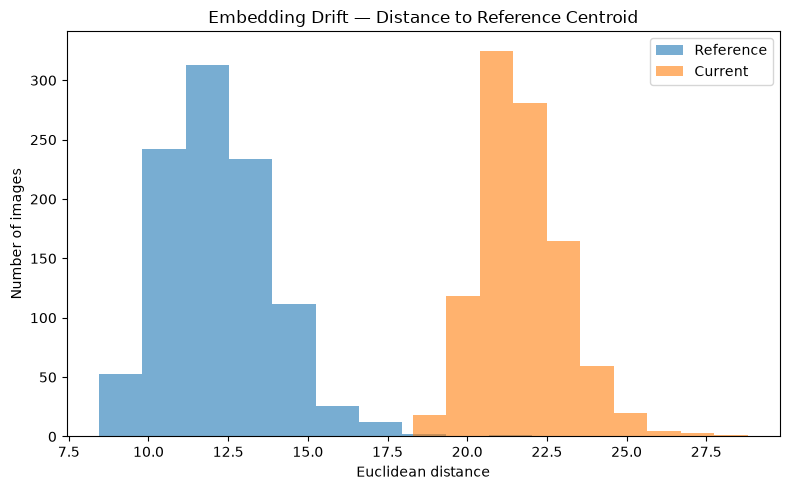

In [14]:
# Visualise the distance distributions for the reference and current embeddings.
import matplotlib.pyplot as plt


fig, ax = plt.subplots(
    figsize=(8, 5)
)

# Plot histograms of the reference and current distance distributions, using 10 bins for each histogram,
# with an alpha transparency of 0.6, and labeling them as "Reference" and "Current" respectively for the legend.
ax.hist(
    reference_distances,
    bins=10,
    alpha=0.6,
    label="Reference",
)

ax.hist(
    current_distances,
    bins=10,
    alpha=0.6,
    label="Current",
)

ax.set_title(
    "Embedding Drift — Distance to Reference Centroid"
)

ax.set_xlabel(
    "Euclidean distance"
)

ax.set_ylabel(
    "Number of images"
)

ax.legend()

plt.tight_layout()
plt.show()

### Embedding-distance interpretation

The histogram shows a clear shift in the model's learned feature space between
the clean reference batch and the simulated current production batch.

Reference embeddings are concentrated relatively close to the fixed reference
centroid, while embeddings from the current batch are located substantially
further away. The two distance distributions show almost no overlap, indicating
that the simulated image degradation has caused a large change in the internal
representations produced by the ResNet18 backbone.

This visual separation is consistent with the calculated embedding PSI of
approximately `12.4219`, which is far above the configured embedding-drift
threshold of `0.10`. Embedding drift is therefore detected.

The result is important because it demonstrates that the production shift is
not limited to simple image characteristics such as brightness or sharpness.
The change is also visible in the 512-dimensional feature representation used
by the trained model, providing complementary evidence of model-relevant drift.

The reference centroid remains fixed and is derived only from the clean
production baseline. Both reference and current embeddings are measured
against this same centroid, ensuring that the comparison represents movement
relative to the established production feature-space baseline.

### Stage 4.3 interpretation

The production ResNet18 model was reused as a feature extractor by removing its
final classification layer. Each image was represented by the model's
**512-dimensional penultimate-layer embedding**.

The fixed clean production-monitoring baseline was created from the complete
validation split associated with dataset version `v1`. It contained **995
reference embeddings with shape `(995, 512)`**. The simulated current production
batch also contained **995 embeddings with shape `(995, 512)`**.

The stored reference embeddings were regenerated using the currently loaded
production model and verified to match within the configured numerical
tolerance. The reference centroid had shape `(512,)`, confirming that the
saved baseline is consistent with the deployed model and can be used as the
fixed feature-space reference.

Each reference and current embedding was reduced to its Euclidean distance from
this fixed clean-reference centroid. This produced one distance distribution
for the reference batch and another for the simulated current batch.

The histogram shows a very clear separation between these distributions.
Reference embeddings are concentrated at substantially lower distances from
the centroid, while current embeddings are shifted much further away. There is
very little overlap between the two distributions, indicating that the
simulated production corruption has caused a large change in the internal
feature representations learned by ResNet18.

The resulting embedding PSI was approximately **12.4219**, which is far above
the configured embedding-drift threshold of **0.10**. Embedding drift was
therefore detected.

The unusually large PSI value is consistent with the strong visual separation
between the reference and current distance distributions. It should be
interpreted as evidence of severe simulated feature-space drift rather than as
a fine-grained measure of how much one individual representation dimension has
changed.

#### Relationship between statistical and embedding drift

Stage 4.2 measures drift using **human-interpretable image characteristics**
such as brightness, contrast, edge density, sharpness and mean intensity.
These measurements determine whether the observable input distribution has
changed.

Stage 4.3 instead measures drift in the model's **learned 512-dimensional
feature space**. It therefore determines whether incoming images have changed
in a way that is also reflected in the internal representation used by the
classifier.

The two signals are complementary. Statistical drift can identify changes in
observable image properties, while embedding drift provides evidence that the
same shift has propagated into the representation learned by the model.

In this experiment, both statistical feature drift and embedding drift were
detected. Mean prediction confidence decreased from approximately **0.8706**
to **0.8293**, but the absolute drop of approximately **0.0412** remained below
the configured confidence-alert threshold of **0.10**.

This demonstrates why operational monitoring benefits from combining multiple
signals rather than relying on prediction confidence alone. Even though the
confidence alert did not trigger, both the interpretable feature distributions
and the learned embedding space showed substantial drift, resulting in a
retraining recommendation.

## **Stage 4.4 — Retraining Workflow & Triggers** <font color="red">[6 marks]</font>

- **4.4.1 — Measurable retraining triggers [2]** — *to be done in this notebook and the report*
- **4.4.2 — Drift-triggered retraining + new version registered [4]** — *to be done in this notebook and the report*

**Objective:** Retrain a candidate when drift fires.

**Implement in:** src/retrain.py

**Inputs → Outputs:** drift signals → drift-augmented candidate model + new registry version

**TODO:** define multi-signal triggers (drift share / embedding PSI / confidence drop) (4.4.1); on a trigger, train a drift-augmented candidate + register a new version (4.4.2).

**Document here:** the trigger decision + candidate training summary.

In [17]:
# Stage 4.4.1 — Measurable retraining triggers

assert drift_summary is not None

# Extract the feature drift, embedding drift, and confidence metrics from the drift summary for further analysis and display.
feature_drift = (
    drift_summary["feature_drift"]
)

embedding_drift = (
    drift_summary["embedding_drift"]
)

confidence = (
    drift_summary["confidence"]
)

# Create a DataFrame to summarize the retraining triggers, including the signal name, threshold value, observed value, and whether the 
# trigger was activated based on the observed value exceeding the threshold.
trigger_evidence = pd.DataFrame(
    [
        # Signal, Threshold, Observed, Triggered        
        {
            "Signal":
                "Drifted feature share",
            "Threshold":
                config.DRIFT_SHARE_THRESHOLD,
            "Observed":
                feature_drift[
                    "drift_share"
                ],
            "Triggered":
                feature_drift[
                    "dataset_drift"
                ],
        },
        {
            "Signal":
                "Embedding PSI",
            "Threshold":
                config.EMBEDDING_DRIFT_THRESHOLD,
            "Observed":
                embedding_drift[
                    "psi"
                ],
            "Triggered":
                embedding_drift[
                    "drifted"
                ],
        },
        {
            "Signal":
                "Confidence drop",
            "Threshold":
                config.CONFIDENCE_DROP_THRESHOLD,
            "Observed":
                confidence[
                    "drop"
                ],
            "Triggered":
                confidence[
                    "alert"
                ],
        },
    ]
)

display(
    trigger_evidence.style.format(
        {
            "Threshold": "{:.4f}",
            "Observed": "{:.4f}",
        }
    )
)

print(
    "Retraining recommended:",
    drift_summary[
        "retrain_recommended"
    ],
)

print(
    "Trigger reasons:",
    drift_summary[
        "trigger_reasons"
    ],
)

,Signal,Threshold,Observed,Triggered
0,Drifted feature share,0.4000,1.0000,True
1,Embedding PSI,0.1000,12.4219,True
2,Confidence drop,0.1000,0.0412,False


Retraining recommended: True
Trigger reasons: ['feature_drift', 'embedding_drift']


In [18]:
# TODO 4.4.1-4.4.2: !python -m src.retrain ; load artifacts/retraining_decision.json
# Stage 4.4 — Retraining triggers and candidate training
# Stage 4.4.2 — Drift-triggered candidate retraining

import os
import subprocess
import sys
import json

from src.retrain import RETRAIN_CORRUPT_FRACTION

retraining_env = os.environ.copy()

# Use the same CPU-friendly stratified training cap as
# the final production-model training workflow.
retraining_env["MAX_TRAIN_IMAGES"] = "2500"

# Maximum epoch. Early stopping may finish sooner.
retraining_env["EPOCHS"] = "10"

print("Final retraining configuration")
print("------------------------------")
print(
    "Dataset version:",
    drift_summary["dataset_version"],
)
print(
    "Training image cap:",
    retraining_env["MAX_TRAIN_IMAGES"],
)
print(
    "Maximum epochs:",
    retraining_env["EPOCHS"],
)
print(
    "Early-stopping patience:",
    config.EARLY_STOP_PATIENCE,
)
print(
    "Drift corruption fraction:",
    RETRAIN_CORRUPT_FRACTION,
)
print(
    "Device:",
    config.DEVICE,
)

# Assert that retraining is recommended based on the drift summary to ensure that the retraining workflow is only executed when necessary.
assert (
    drift_summary["retrain_recommended"]
    is True
)

# Run the retraining workflow as a subprocess, using the same Python executable and specifying the "src.retrain" module to be executed.
retraining_result = subprocess.run(
    [
        sys.executable,
        "-m",
        "src.retrain",
    ],
    cwd=config.BASE_DIR,
    env=retraining_env,
    text=True,
)

# Assert that the retraining workflow completed successfully by checking the return code of the subprocess.
assert retraining_result.returncode == 0, (
    "Retraining workflow failed."
)

print(
    "PASS: drift-triggered retraining "
    "workflow completed."
)

# Load the decision generated by this run.
retraining_decision_path = (
    config.ARTIFACT_DIR
    / "retraining_decision.json"
)

assert retraining_decision_path.exists()

# Load the retraining decision from the JSON file generated by the retraining workflow, which contains information about 
# whether retraining was triggered, the reasons for the trigger, and the candidate model version.
retraining_decision = json.loads(
    retraining_decision_path.read_text(
        encoding="utf-8"
    )
)

print(
    "\nRetraining triggered:",
    retraining_decision[
        "retrain_triggered"
    ],
)

print(
    "Trigger reasons:",
    retraining_decision[
        "trigger_reasons"
    ],
)

print(
    "Candidate version:",
    retraining_decision[
        "candidate_version"
    ],
)

Final retraining configuration
------------------------------
Dataset version: v1
Training image cap: 2500
Maximum epochs: 10
Early-stopping patience: 3
Drift corruption fraction: 0.4
Device: cpu
PASS: drift-triggered retraining workflow completed.

Retraining triggered: True
Trigger reasons: ['feature_drift', 'embedding_drift']
Candidate version: 2


In [21]:
import pandas as pd
from IPython.display import display


trigger_rows = []

# Iterate over the trigger signals in the retraining decision and create a list of dictionaries containing the signal name, 
# observed value, threshold, and whether the trigger was activated.
for signal_name, details in (
    retraining_decision[
        "trigger_signals"
    ].items()
):
    # Append a dictionary representing the trigger signal to the trigger_rows list, including the signal name, observed value, 
    # threshold, and whether the trigger was activated.
    trigger_rows.append(
        {
            "Signal": signal_name,
            "Observed value":
                details["value"],
            "Threshold":
                details["threshold"],
            "Triggered":
                details["fired"],
        }
    )


trigger_table = pd.DataFrame(
    trigger_rows
)

display(
    trigger_table.style.format(
        {
            "Observed value":
                "{:.4f}",
            "Threshold":
                "{:.4f}",
        }
    )
)

,Signal,Observed value,Threshold,Triggered
0,feature_drift,1.0000,0.4000,True
1,embedding_drift,12.4219,0.1000,True
2,confidence_drop,0.0412,0.1000,False


In [22]:
# Display the candidate training summary, including dataset version, number of training and validation images,
# drift corruption fraction, epochs completed, best epoch, best validation F1 score, MLflow run ID, and registered candidate version, 
# for structured analysis and review of the retraining process.

# Extract the candidate training information from the retraining decision for further analysis and display.
candidate = retraining_decision[
    "candidate_training"
]

# Create a DataFrame to summarize the candidate training information, including dataset version, number of training and validation images,
candidate_summary = pd.DataFrame(
    {
        "Property": [
            "Dataset version",
            "Training images",
            "Validation images",
            "Drift corruption fraction",
            "Epochs completed",
            "Best epoch",
            "Best validation F1",
            "MLflow run ID",
            "Registered candidate version",
        ],

        "Value": [
            candidate[
                "dataset_version"
            ],
            candidate[
                "training_images"
            ],
            candidate[
                "validation_images"
            ],
            candidate[
                "corrupt_fraction"
            ],
            candidate[
                "epochs_completed"
            ],
            candidate[
                "best_epoch"
            ],
            candidate[
                "best_val_f1"
            ],
            candidate[
                "mlflow_run_id"
            ],
            candidate[
                "candidate_version"
            ],
        ],
    }
)

display(
    candidate_summary
)

,Property,Value
0,Dataset version,v1
1,Training images,2500
2,Validation images,995
3,Drift corruption fraction,0.4
4,Epochs completed,5
5,Best epoch,2
6,Best validation F1,0.901926
7,MLflow run ID,b79cba943e7b4614b02c4a635670d974
8,Registered candidate version,2


### Stage 4.4 interpretation

The monitoring workflow recommended retraining because two independent drift
signals exceeded their configured thresholds: statistical feature drift and
embedding drift. The confidence-drop signal did not independently trigger.

Retraining was performed using dataset version `v1`. To keep the CPU workflow
practical and consistent with the original production-model training process,
the retraining set was capped at **2,500 stratified training images**, while the
complete **995-image validation split** was retained for model selection.

The candidate model was initialized from the current production checkpoint.
Approximately **40% of the retraining data** was exposed to the simulated
production corruption, while the remaining images stayed clean. This allowed
the candidate to adapt to the observed drift without training exclusively on
corrupted images.

A maximum of **10 epochs** was configured with early-stopping patience of
**3 epochs**. Training stopped after **5 epochs**, with the best checkpoint
occurring at **epoch 2**.

The best validation defect F1 achieved by the drift-augmented candidate was
approximately **0.9019**.

The candidate model was logged to MLflow under run ID
`b79cba943e7b4614b02c4a635670d974` and registered as model version **2**.

At this stage the model is only a candidate. Registration alone does not move
the production alias. Promotion is decided separately in Stage 4.5 by comparing
the incumbent production model and candidate model on the same fully drifted
evaluation batch.

## **Stage 4.5 — Version Comparison & Rollback Governance** <font color="red">[4 marks]</font>

- **4.5.1 — Candidate vs production comparison on drifted batch [2]** — *to be done in this notebook and the report*
- **4.5.2 — Promote-on-improvement-else-rollback gate + decision recorded [2]** — *to be done in this notebook and the report*

**Objective:** Promote only on improvement; otherwise roll back.

**Implement in:** src/retrain.py

**Inputs → Outputs:** candidate vs production on a drifted batch → promote (alias move) OR rollback

**TODO:** compare candidate vs production F1 on the drifted batch (4.5.1); promote to @production only if candidate ≥ prod + epsilon else keep the incumbent + record the decision/version history (4.5.2).

**Document here:** the comparison numbers + the promote/rollback decision.

In [23]:
# TODO 4.5.1-4.5.2: from retraining_decision.json show prod vs candidate F1 + action + production version

# Stage 4.5 — Version comparison and promotion governance

# Extract the comparison information from the retraining decision for further analysis and display.
comparison = (
    retraining_decision[
        "comparison"
    ]
)

# Extract individual comparison metrics from the comparison dictionary for easier access and display.
production_f1 = float(
    comparison[
        "production_drifted_f1"
    ]
)

candidate_f1 = float(
    comparison[
        "candidate_drifted_f1"
    ]
)

promotion_epsilon = float(
    comparison[
        "promotion_epsilon"
    ]
)

required_candidate_f1 = float(
    comparison[
        "required_candidate_f1"
    ]
)

# Create a DataFrame to summarize the comparison metrics, including production drifted defect F1 score, candidate drifted defect F1 score,
# promotion epsilon, and the required candidate F1 score for promotion, for structured analysis and review of the retraining decision.
comparison_table = pd.DataFrame(
    {
        "Metric": [
            "Production drifted defect F1",
            "Candidate drifted defect F1",
            "Promotion epsilon",
            "Required candidate F1",
        ],
        "Value": [
            production_f1,
            candidate_f1,
            promotion_epsilon,
            required_candidate_f1,
        ],
    }
)

display(
    comparison_table.style.format(
        {
            "Value": "{:.4f}"
        }
    )
)


print(
    "Production version before:",
    retraining_decision[
        "production_version_before"
    ],
)

print(
    "Candidate version:",
    retraining_decision[
        "candidate_version"
    ],
)

print(
    "Governance action:",
    retraining_decision[
        "action"
    ],
)

print(
    "Production version after:",
    retraining_decision[
        "production_version_after"
    ],
)

# Check that the candidate F1 meets the required threshold for promotion to production, and print whether the candidate passes the promotion gate.
candidate_passes_gate = (
    candidate_f1
    >= required_candidate_f1
)

print(
    "\nCandidate passes promotion gate:",
    candidate_passes_gate,
)

# Assert that the candidate passes the promotion gate if and only if the retraining decision action is "promote", ensuring that the 
# governance action aligns with the configured promotion rule based on the candidate's performance.
assert candidate_passes_gate == (
    retraining_decision[
        "action"
    ]
    == "promote"
)

assert (
    retraining_decision[
        "production_version_after"
    ]
    == retraining_decision[
        "candidate_version"
    ]
)

print(
    "PASS: recorded governance action follows "
    "the configured promotion rule."
)


,Metric,Value
0,Production drifted defect F1,0.4049
1,Candidate drifted defect F1,0.8982
2,Promotion epsilon,0.0100
3,Required candidate F1,0.4149


Production version before: 1
Candidate version: 2
Governance action: promote
Production version after: 2

Candidate passes promotion gate: True
PASS: recorded governance action follows the configured promotion rule.


In [24]:
# Verify the final MLflow production alias.

from mlflow import MlflowClient

from src.train import mlflow_tracking_uri

client = MlflowClient(
    tracking_uri=mlflow_tracking_uri()
)

# Retrieve the production model version from MLflow using the registered model name and the production alias,
# and store the version number as a string for comparison with the recorded governance decision.
production_model_version = (
    client.get_model_version_by_alias(
        name=config.REGISTERED_MODEL,
        alias=config.PRODUCTION_ALIAS,
    )
)

# Retrieve the production model version from MLflow using the registered model name and the production alias,
registry_production_version = str(
    production_model_version.version
)

print(
    "Recorded production version after:",
    retraining_decision[
        "production_version_after"
    ],
)

print(
    "MLflow @production version:",
    registry_production_version,
)

assert (
    registry_production_version
    == retraining_decision[
        "production_version_after"
    ]
)

print(
    "PASS: MLflow production alias matches "
    "the recorded governance decision."
)

2026/08/17 08:25:26 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/17 08:25:26 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2026/08/17 08:25:27 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/17 08:25:27 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


Recorded production version after: 2
MLflow @production version: 2
PASS: MLflow production alias matches the recorded governance decision.


### Stage 4.5 interpretation

The incumbent production model and the newly retrained candidate were evaluated
on the **same fully drifted evaluation batch** so that the promotion decision
was based on a like-for-like comparison under the simulated production shift.

The incumbent production model, version **1**, achieved a drifted defect F1 of
approximately **0.4049**. This substantial reduction from its original clean-data
performance demonstrates that the simulated production drift materially affected
the model's ability to identify defective castings.

The drift-augmented candidate, registered as model version **2**, achieved a
drifted defect F1 of approximately **0.8982** on the same evaluation batch. This
represents an absolute F1 improvement of approximately **0.4933** over the
incumbent model under the simulated drift condition.

The promotion policy requires the candidate defect F1 to be at least the
production defect F1 plus the configured promotion epsilon of **0.01**:

`required candidate F1 = 0.4049 + 0.0100 = 0.4149`

The candidate achieved **0.8982**, which substantially exceeded the required
promotion threshold of **0.4149**. The promotion gate therefore passed.

As a result, candidate model version **2** was promoted to production and the
MLflow `@production` alias was moved from version **1** to version **2**.

The recorded governance decision was independently checked against the MLflow
Model Registry. The decision artifact recorded production version **2** after
promotion, and the MLflow `@production` alias also resolved to version **2**.
This confirms that the registry state is consistent with the recorded promotion
decision.

The workflow therefore demonstrates controlled model governance rather than
automatically deploying every retrained model. A candidate is first registered
for traceability, evaluated against the incumbent on a common drifted batch,
and promoted only when it satisfies the predefined improvement criterion.
Had the candidate failed this gate, the production alias would have remained on
the incumbent version.